# resonant-tunneling diode 

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from typing import Callable
from typing import Tuple

plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 

def eV2au(eV: float):
    return 0.036749325871*eV

def nm2au(nm: float):
    return 18.897261339*nm

def K2au(K: float):
    return K/315775.13

In [2]:
def Monodromy_matrix(z_n: float, z_n1: float, E: float,
                    V: Callable[[float], float], m_eff: Callable[[float], float]) -> np.ndarray:

    '''
    z_n, z_n1 - positions monodromy matrix elements are computed between;
    E - energy of an electron;
    V, m_eff - functions of position defining electric potential and effective mass parameter
    '''

    # (1) eff. mass params. at the current site and at the next site
    m = m_eff(z_n)
    m1 = m_eff(z_n1)

    # (2) electric potential at the current site and at the next site
    U = V(z_n)
    U1 = V(z_n1)

    # (3) wave vector values associated with the current site and the next site
    k = np.sqrt(2.0*m*(E - U) + 0j)
    k1 = np.sqrt(2.0*m1*(E - U1) + 0j)

    # (4) monodromy matrix elements
    alpha = k1*m/k/m1
    M_11 = 0.5*(1.0 + alpha)*np.exp(1j*z_n*(k1 - k))
    M_12 = 0.5*(1.0 - alpha)*np.exp(-1j*z_n*(k1 + k))
    M_21 = 0.5*(1.0 - alpha)*np.exp(1j*z_n*(k1 + k))
    M_22 = 0.5*(1.0 + alpha)*np.exp(-1j*z_n*(k1 - k))

    return np.array([[M_11, M_12], [M_21, M_22]])

def transmission_reflection(linspace: np.ndarray, E: float,
                            V: Callable[[float], float], m_eff: Callable[[float], float]) -> Tuple[float, float, np.ndarray]:
    
    '''
    linspace - positions monodromy matrix elements are computed at;
    E - energy of an electron;
    V, m_eff - functions of position defining electric potential and effective mass parameter
    '''
    
    # (1) component monodromy matrices
    dz = linspace[1] - linspace[0]
    M_matrices = [Monodromy_matrix(z, z + dz, E, V, m_eff) for z in linspace[:-1]]

    # (2) eff. mass params at the first site and at the last site
    m = m_eff(linspace[0])
    mn = m_eff(linspace[-1])

    # (3) electric potential at the first site and at the last site
    U = V(linspace[0])
    Un = V(linspace[-1])

    # (4) wave vector values associated with the first site and the last site
    k = np.sqrt(2.0*m*(E - U) + 0j)
    kn = np.sqrt(2.0*mn*(E - Un) + 0j)

    # (5) a total monodromy matrix
    M_matrix = np.identity(2)
    for M_step in M_matrices:
        M_matrix = M_matrix @ M_step

    # (6) transmission (t) and reflection (r) coefficients
    t = (kn/k)*(m/mn)/np.abs(M_matrix[0,0])**2
    r = np.abs(M_matrix[1,0]/M_matrix[0,0])**2

    return (np.abs(t), r, M_matrix)

# bariera potencjału

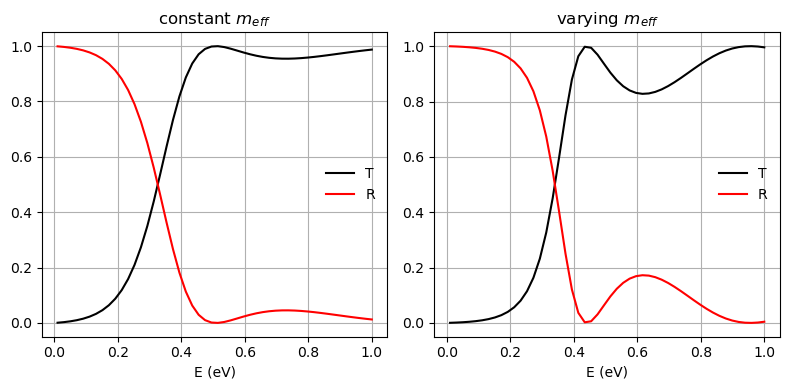

In [ ]:
# electric potential of a single barrier
def V(z: float) -> float: 

    if nm2au(0.0) < z < nm2au(5.0):
        return eV2au(0.27) # AlGaAs
    else:
        return 0.0 # GaAs

# eff. mass depending on the material
def m_eff(z: float) -> float:

    x = 0.3 # doping: Al(x)Ga(1-x)As
    m0 = 1.0

    if nm2au(0.0) < z < nm2au(5.0):
        return (0.063 + 0.083*x)*m0 # AlGaAs
    else:
        return 0.063*m0 # GaAs

# constant eff. mass
def m_eff_const(z: float) -> float:

    m0 = 1.0
    return 0.063*m0

# calculations for a set range in energy and in space
z_linspace = np.linspace(nm2au(0.0), nm2au(5.0), 1000)
Es = np.linspace(eV2au(0.01), eV2au(1.0), 50)

Ts_1, Ts_2, Rs_1, Rs_2 = [], [], [], []
for E in Es:

    # calculations for a constant eff. mass
    T_1, R_1, M_matrix_1 = transmission_reflection(z_linspace, E, V, m_eff_const)
    Ts_1.append(T_1)
    Rs_1.append(R_1)

    # calculations for a varying eff. mass
    T_2, R_2, M_matrix_2 = transmission_reflection(z_linspace, E, V, m_eff)
    Ts_2.append(T_2)
    Rs_2.append(R_2)

# plotting
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(Es/eV2au(1.0), Ts_1, label = 'T', color = 'k')
ax[0].plot(Es/eV2au(1.0), Rs_1, label = 'R', color = 'r')
ax[0].grid(True)
ax[0].legend(frameon=False)
ax[0].set_xlabel('E (eV)')
ax[0].set_title(r"constant $m_{eff}$")

ax[1].plot(Es/eV2au(1.0), Ts_2, label = 'T', color = 'k')
ax[1].plot(Es/eV2au(1.0), Rs_2, label = 'R', color = 'r')
ax[1].grid(True)
ax[1].legend(frameon=False)
ax[1].set_xlabel('E (eV)')
ax[1].set_title(r"varying $m_{eff}$")

plt.tight_layout()
plt.savefig('fig1.pdf', format = 'pdf')
plt.show()

# RTD

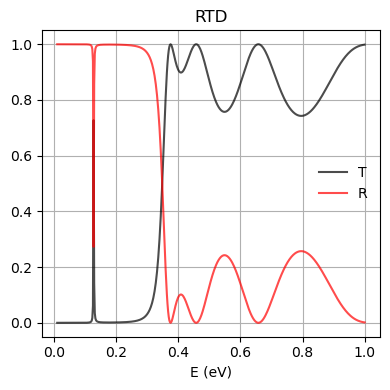

In [ ]:
# electric potential of the RTD
def v_rtd(z: float) -> float: 

    if (nm2au(0.0) < z < nm2au(5.0)) or (nm2au(8.0) < z < nm2au(13.0)):
        return eV2au(0.27) # AlGaAs
    else:
        return 0.0 # GaAs

# eff. mass depending on the material
def m_eff_rtd(z: float) -> float:

    x = 0.3 # doping: Al(x)Ga(1-x)As
    m0 = 1.0

    if (nm2au(0.0) < z < nm2au(5.0)) or (nm2au(8.0) < z < nm2au(13.0)):
        return (0.063 + 0.083*x)*m0 # AlGaAs
    else:
        return 0.063*m0 # GaAs

# calculations for a set range in energy and in space
z_linspace = np.linspace(nm2au(0.0), nm2au(13.0), 50)
Es = np.linspace(eV2au(0.01), eV2au(1.0), 500)

Ts_3, Rs_3 = [], []
for E in Es:

    # calculations for the RTD
    T_3, R_3, M_matrix_3 = transmission_reflection(z_linspace, E, v_rtd, m_eff_rtd)
    Ts_3.append(T_3)
    Rs_3.append(R_3)

# plotting
plt.figure(figsize=(4, 4))
plt.plot(Es/eV2au(1.0), Ts_3, label = 'T', color = 'k', alpha = 0.7)
plt.plot(Es/eV2au(1.0), Rs_3, label = 'R', color = 'r', alpha = 0.7)
plt.grid(True)
plt.legend(frameon=False)
plt.xlabel('E (eV)')
plt.title(r"RTD")

plt.tight_layout()
plt.savefig('fig2.pdf', format = 'pdf')
plt.show()

# Tsu-Esaki RTD

In [5]:
# (I) electric potential of the RTD
def make_electric_field(voltage: float, distance: float) -> Callable[[float], float]:

    electric_field = -voltage/distance

    def v_rtd(z: float) -> float:

        if (nm2au(0.0) < z < nm2au(5.0)) or (nm2au(8.0) < z < nm2au(13.0)):
            return eV2au(0.27) + electric_field*z # AlGaAs + bias
        else:
            return electric_field*z # GaAs + bias
    
    return v_rtd

# (II) eff. mass depending on the material
def m_eff_rtd(z: float) -> float:

    x = 0.3 # doping: Al(x)Ga(1-x)As
    m0 = 1.0

    if (nm2au(0.0) < z < nm2au(5.0)) or (nm2au(8.0) < z < nm2au(13.0)):
        return (0.063 + 0.083*x)*m0 # AlGaAs
    else:
        return 0.063*m0 # GaAs

# (III) current with Tsu-Esaki formula
def j(mu_s: float, mu_d: float, temperature: float,
    m_eff: Callable[[float], float]) -> Callable[[float], float]:

    # (1) integration over electron energy range 
    energy_range, dE = np.linspace(eV2au(0.1e-3), mu_s, 500, retstep = True)

    # (2) RTD diode spatial range
    z_linspace, dz = np.linspace(nm2au(0.0), nm2au(13.0), 50, retstep = True)
    z_length = z_linspace[-1] - z_linspace[0]

    # (3) average effective mass for simplicity
    m_eff_average = np.sum([m_eff(z) for z in z_linspace])/50.0

    # (4) Tsu-Esaki formula constant
    constant = 0.5*m_eff_average/temperature/np.pi**2

    def tsu_esaki_formula(voltage: float) -> float:

        # (5) transmission coeffs to be calculated over electron energy range (1)
        transmission = np.zeros_like(energy_range)

        # (6) electric potential taking bias voltage into account with (I)
        v_rtd_biased = make_electric_field(voltage, z_length)
        
        # (7) calculating transmission coeffs over electron energy range (1)
        for i, E in enumerate(energy_range):
            T_loc, R_loc, M_matrix_loc = transmission_reflection(z_linspace, E, v_rtd_biased, m_eff)
            transmission[i] = T_loc

        # (8) logarithmic function of energy taken directly from Tsu-Esaki formula as a weight function
        numerator = np.exp(np.clip((mu_s - energy_range)/temperature, -100, 100)) # clip to get rid of nan values
        denumerator = np.exp(np.clip((mu_d - energy_range - voltage)/temperature, -100, 100))
        logarithm = np.log1p(numerator) - np.log1p(denumerator)

        # (9) Tsu-Esaki formula: integrating over energy range (1)
        current = constant*np.sum(transmission*logarithm)*dE

        return current 
    
    return tsu_esaki_formula

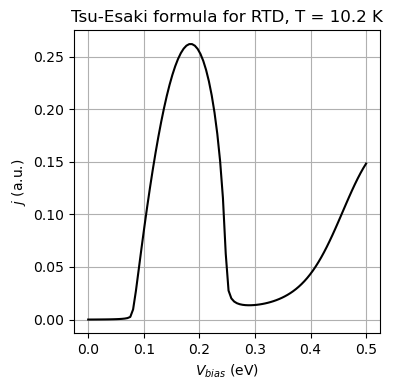

In [ ]:
# temperature of the electron gas
temperature = K2au(10.2)

# defining Tsu-Esaki formula parameters (curr is a function of V_bias)
curr = j(mu_s = eV2au(87e-3), mu_d = eV2au(87e-3), temperature = temperature, m_eff = m_eff_rtd)

# range of energy to calculate the current for
e_range = np.linspace(eV2au(0.0), eV2au(0.5), 100)

# calculating current
curs = [curr(volt) for volt in e_range]

# plotting
plt.figure(figsize=(4, 4))
plt.plot(e_range/eV2au(1.0), curs, color = 'k')
plt.grid(True)
plt.xlabel(r'$V_{bias}$ (eV)')
plt.ylabel(r'$j$ (a.u.)')
plt.title(f"Tsu-Esaki formula for RTD, T = {temperature/K2au(1.0):.3} K")
plt.tight_layout()
plt.savefig('fig3.pdf', format = 'pdf')
plt.show()

# QPC

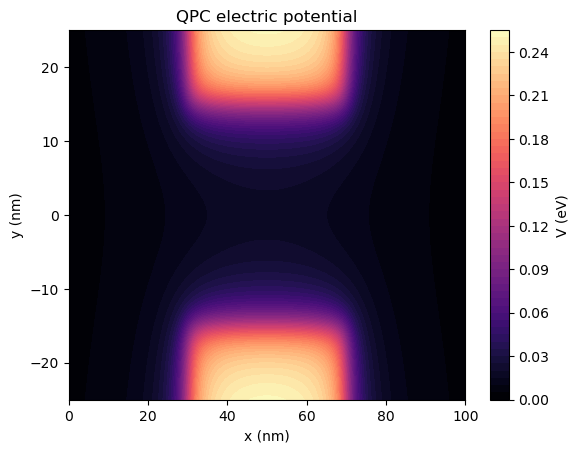

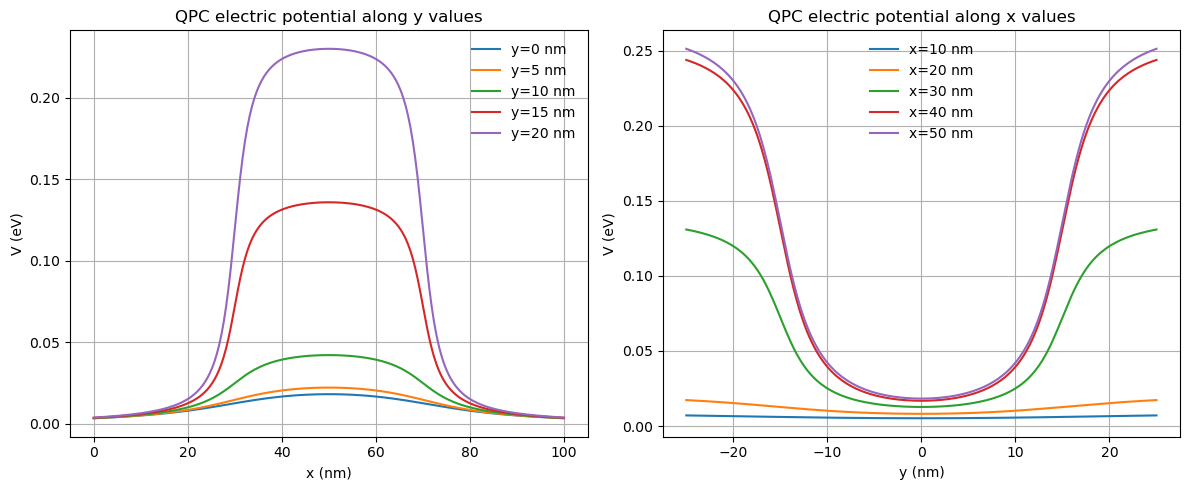

In [7]:
def make_potential_QPC(left: float, right: float,
                    dist: float = nm2au(20.0),
                    V_g1: float = eV2au(4.0), V_g2: float = eV2au(4.0)) -> Callable[[float, float], float]:

    '''
    left, right - QPC gates range in x direction;\
    dist - distance between QPC gates in y direction;\
    V_g1, V_g2 - QPC gate voltages
    '''

    epsilon = 13.6
    constant = 0.5/np.pi/epsilon

    # QPC distance from 2DEG
    d = nm2au(3.0)

    def f(u,v):
        return constant*np.arctan(u*v/(d*np.sqrt(d**2 + u**2 + v**2)))

    def g(x_pos, y_pos, l, b, t, r):

        f1 = f(x_pos - l, y_pos - b)
        f2 = f(x_pos - l, t - y_pos)
        f3 = f(r - x_pos, y_pos - b)
        f4 = f(r - x_pos, t - y_pos)

        return f1 + f2 + f3 + f4

    l = left
    r = right

    b1 = dist/2.0
    t1 = 10.0*dist

    b2 = -dist/2.0
    t2 = -10.0*dist

    def potential(x,y):
        return V_g1*g(x, y, l, b1, t1, r) - V_g2*g(x, y, l, b2, t2, r)

    return potential

# plotting
L = nm2au(100.0)
W = nm2au(50.0)
W_qpc = 0.6*nm2au(50.0)

x = np.linspace(0.0, L, 200)
y = np.linspace(-W/2, W/2, 200)
X, Y = np.meshgrid(x, y)

left = 0.3*L
right = 0.7*L
potential_QPC = make_potential_QPC(left, right, W_qpc)

fig, ax = plt.subplots()
Z = np.vectorize(lambda x, y: potential_QPC(x, y))(X, Y)
heatmap = plt.contourf(X/nm2au(1.0), Y/nm2au(1.0), Z/eV2au(1.0), levels=50, cmap='magma')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical', label='V (eV)')
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.title('QPC electric potential')
plt.savefig('QPC_potential.pdf', format='pdf')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

y_values = [i*W/2/5 for i in range(5)]
for y_val in y_values:
    potential_along_x = [potential_QPC(x_val, y_val) for x_val in x]
    ax[0].plot(x/nm2au(1.0), np.array(potential_along_x)/eV2au(1.0), label=f'y={y_val/nm2au(1.0):.0f} nm')

ax[0].set_xlabel('x (nm)')
ax[0].set_ylabel('V (eV)')
ax[0].legend(frameon=False)
ax[0].grid(True)
ax[0].set_title('QPC electric potential along y values')

x_values = [L/2 - i*L/10 for i in range(5)]
for x_val in x_values[::-1]:
    potential_along_y = [potential_QPC(x_val, y_val) for y_val in y]
    ax[1].plot(y/nm2au(1.0), np.array(potential_along_y)/eV2au(1.0), label=f'x={x_val/nm2au(1.0):.0f} nm')

ax[1].set_xlabel('y (nm)')
ax[1].set_ylabel('V (eV)')
ax[1].legend(frameon=False)
ax[1].grid(True)
ax[1].set_title('QPC electric potential along x values')

fig.tight_layout()
plt.savefig('QPC_potential_profiles.pdf', format='pdf')
plt.show()


In [8]:
def find_En(m_eff: float, qpc_v: Callable[[float, float], float],
            y_range: Tuple[float, float], n_y_stripes: int,
            x_range: Tuple[float, float], n_x_stripes: int):

    '''
    calculates eigen-energies of certain "stripes" along the 2D device's width:
    m_eff - eff. mass of an electron;
    qpc_v - electric potential in the 2DEG plane;
    y_range - y-positioning of a device, n_y_stripes - number of steps in width;
    y_range - x-positioning of a device, n_x_stripes - number of steps in length
    '''

    # (1) device's y spatial range
    positions_y, dy = np.linspace(y_range[0], y_range[1], n_y_stripes, retstep = True)

    # (2) device's x spatial range
    positions_x, dx = np.linspace(x_range[0], x_range[1], n_x_stripes, retstep = True)

    # (3) constant that shows up when you discretize Schroedinger equation
    alpha = -.5/m_eff/dy**2.0
    
    # (4) finding E_n(x) values
    Ens = np.empty((n_x_stripes, n_y_stripes))
    for i, x in enumerate(positions_x): # for each x in a length of a device

        # (4.1) creating a Hamiltonian of a single "y-stripe"
        y_Hamiltonian = np.zeros((n_y_stripes, n_y_stripes))
        for j, y in enumerate(positions_y): # for each "stripe" in a width of a device

            # (4.1.1) diagonal elements of the Hamiltonian
            y_Hamiltonian[j,j] = -2.0*alpha + qpc_v(x, y)
            
            # (4.1.2) non-diagonal elements of the Hamiltonian
            if(j < n_y_stripes - 1):
                y_Hamiltonian[j+1,j] = alpha
                y_Hamiltonian[j,j+1] = alpha

        # Hamiltonian diagonalization -> self-energies
        Ens[i, :] = np.linalg.eigvalsh(y_Hamiltonian)
    
    # returns transposed values so n-th element can depict n-th mode
    return Ens.T

def landauer_formula_single_mode(energy: float, m_eff: float, E_n: np.ndarray,
            y_range: Tuple[float, float], n_y_stripes: int,
            x_range: Tuple[float, float], n_x_stripes: int):

    '''
    calculates conductance (2e^2/h) of an electron of a given energy,\
    takes an electron into account as a single sinusoidal wave:\
    energy - energy of an electron, m_eff - eff. mass of an electron;\
    E_n - matrix created using find_En function;\
    y_range - y-positioning of a device, n_y_stripes - number of steps in width\
    y_range - x-positioning of a device, n_x_stripes - number of steps in length
    '''

    # (1) eigen-energies of certain "stripes" along the 2D device's width
    # but smaller than electron energy (e- cant reach them anyways)
    En_uee = np.array([Ey for Ey in E_n if 0.0 <= Ey[0] <= energy]) # uee - under electron energy
    if(len(En_uee) == 0):
        return 0.0

    # (2) device's x spatial range
    positions_x, dx = np.linspace(x_range[0], x_range[1], n_x_stripes, retstep = True)

    # (3) unwanted but necessary helper function
    def n_energy_at_x(n):
            
        def energy_at_x(x):
            index = int(round((x - x_range[0])/dx))
            return En_uee[n, index]

        return energy_at_x

    # (4) transmission coeffs with different eigen-energy levels
    Tn = np.zeros(n_y_stripes)
    for n in range(len(En_uee)):

        Tn[n], Rn, M_matrix = transmission_reflection(positions_x, energy,
                                                    n_energy_at_x(n), lambda z: m_eff)

    return np.sum(Tn)

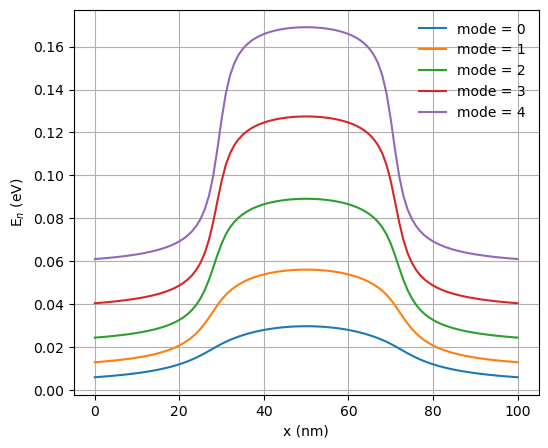

In [ ]:
L = nm2au(100.0) # length of a device
W = nm2au(50.0) # width of a device
W_qpc = 0.6*nm2au(50.0) # width of the QPC
m_eff = 0.063 # effective mass of an electron
n_y_stripes = 101 # number of "y-stripes"
n_x_stripes = 101 # number of "x-stripes"

y_range = (-W/2, W/2); x_range = (0.0, L)
potential_QPC = make_potential_QPC(0.3*L, 0.7*L, W_qpc)
E_n = find_En(m_eff, potential_QPC , y_range, n_y_stripes, x_range, n_x_stripes)

plt.figure(figsize=(6,5))
for mode in range(5):
    plt.plot(np.linspace(x_range[0], x_range[1], n_x_stripes)/nm2au(1.0), 
            E_n[mode]/eV2au(1.0), label=f'mode = {mode}')

plt.xlabel('x (nm)')
plt.ylabel(r'E$_n$ (eV)')
plt.legend(frameon=False)
plt.grid(True)
plt.savefig('fig4_1.pdf', format = 'pdf')

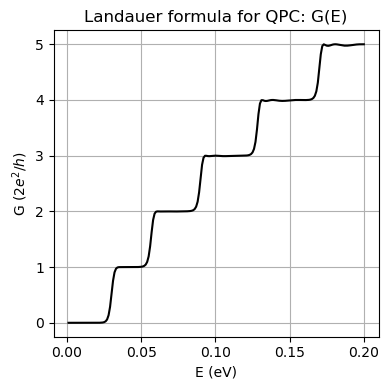

In [ ]:
L = nm2au(100.0) # length of a device
W = nm2au(50.0) # width of a device
W_qpc = 0.6*nm2au(50.0) # width of the QPC
m_eff = 0.063 # effective mass of an electron
n_y_stripes = 101 # number of "y-stripes"
n_x_stripes = 101 # number of "x-stripes"
energy_range = np.linspace(eV2au(0.001), eV2au(.2), 200) # range of energy to calculate G in

y_range = (-W/2, W/2); x_range = (0.0, L)
potential_QPC = make_potential_QPC(0.3*L, 0.7*L, W_qpc)
E_n = find_En(m_eff, potential_QPC , y_range, n_y_stripes, x_range, n_x_stripes)

G = []
for energy in energy_range:
    G.append(landauer_formula_single_mode(energy = energy, m_eff = m_eff, E_n = E_n,
                y_range = y_range, n_y_stripes = n_y_stripes,
                x_range = x_range, n_x_stripes = n_x_stripes))

plt.figure(figsize=(4, 4))
plt.plot(energy_range/eV2au(1.0), G, color = 'k')
plt.grid(True)
plt.xlabel(r'E (eV)')
plt.ylabel(r'G ($2e^2/h$)')
plt.title(r"Landauer formula for QPC: G(E)")

plt.tight_layout()
plt.savefig('fig4_2.pdf', format = 'pdf')
plt.show()

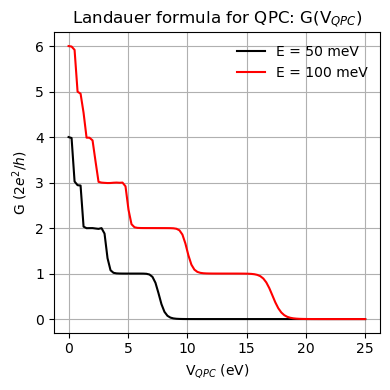

In [ ]:
L = nm2au(100.0) # length of a device
W = nm2au(50.0) # width of a device
W_qpc = 0.6*nm2au(50.0) # width of the QPC
m_eff = 0.063 # effective mass of an electron
n_y_stripes = 101 # number of "y-stripes"
n_x_stripes = 101 # number of "x-stripes"
voltages = np.linspace(0.0, eV2au(25.0), 100) # range of gate voltage to calculate G in

y_range = (-W/2, W/2); x_range = (0.0, L)

G_qpc_50meV = []; G_qpc_100meV = []
for volt in voltages:
    
    potential_QPC = make_potential_QPC(0.3*L, 0.7*L, W_qpc, V_g1 = volt, V_g2 = volt)
    E_n = find_En(m_eff, potential_QPC , y_range, n_y_stripes, x_range, n_x_stripes)

    G_qpc_50meV.append(landauer_formula_single_mode(energy = eV2au(0.05), m_eff = m_eff, E_n = E_n,
                                                    y_range = y_range, n_y_stripes = n_y_stripes,
                                                    x_range = x_range, n_x_stripes = n_x_stripes))

    G_qpc_100meV.append(landauer_formula_single_mode(energy = eV2au(0.1), m_eff = m_eff, E_n = E_n,
                                                    y_range = y_range, n_y_stripes = n_y_stripes,
                                                    x_range = x_range, n_x_stripes = n_x_stripes))

plt.figure(figsize=(4, 4))
plt.plot(voltages/eV2au(1.0), G_qpc_50meV, color = 'k', label = 'E = 50 meV')
plt.plot(voltages/eV2au(1.0), G_qpc_100meV, color = 'r', label = 'E = 100 meV')
plt.grid(True)
plt.legend(frameon=False)
plt.xlabel(r'V$_{QPC}$ (eV)')
plt.ylabel(r'G ($2e^2/h$)')
plt.title(r"Landauer formula for QPC: G(V$_{QPC}$)")

plt.tight_layout()
plt.savefig('fig4_3.pdf', format = 'pdf')
plt.show()